In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# Positional embeddings

In [24]:
block_size = 200
n_embed = 800

In [25]:
emb = nn.Embedding(block_size, n_embed)

In [26]:
emb.weight.shape

torch.Size([200, 800])

In [27]:
emb.weight

Parameter containing:
tensor([[ 1.1988e-01,  1.6844e-01,  3.7142e-01,  ..., -4.1382e-01,
         -7.2051e-01, -1.6826e+00],
        [ 6.8386e-01, -4.4666e-01, -3.8671e-01,  ...,  6.0467e-01,
          5.7634e-01,  7.3038e-01],
        [-1.2597e-03, -8.0961e-01,  8.3672e-02,  ..., -8.4147e-01,
          8.2707e-01,  1.9179e-02],
        ...,
        [ 2.3789e-01,  9.5248e-01, -2.9009e-01,  ..., -3.1277e-01,
          7.6639e-01, -3.7057e-01],
        [ 1.0098e+00, -1.0306e+00,  1.1729e+00,  ...,  7.5283e-01,
         -3.2008e-01,  7.6538e-01],
        [ 1.6854e+00, -6.3964e-01,  4.7790e-01,  ...,  2.6018e-01,
         -1.4324e-01,  9.3408e-01]], requires_grad=True)

In [28]:
emb(torch.tensor([1]))

tensor([[ 6.8386e-01, -4.4666e-01, -3.8671e-01,  1.4798e+00,  1.4159e-01,
          2.1236e+00,  6.3438e-01,  7.5692e-02,  2.2679e+00, -8.1163e-01,
         -8.0057e-01, -4.0022e-01,  1.5722e+00, -5.7274e-01,  1.0593e+00,
          1.1816e+00,  1.2233e+00,  8.8837e-01,  5.3948e-01, -6.9587e-01,
          1.8773e-01, -3.8135e-01,  7.6569e-01,  4.3350e-01, -2.1853e-01,
         -1.1262e+00, -1.2904e+00,  4.3679e-01,  2.4664e-01,  2.7338e-01,
         -7.1017e-01,  2.6543e-01,  1.2536e+00, -6.8240e-01,  1.9944e+00,
         -2.2974e-01, -7.6431e-01, -2.1205e+00,  5.9842e-01,  2.2396e+00,
          5.5874e-01,  6.1221e-01,  3.3196e-01,  1.6064e+00, -5.5150e-02,
         -1.0163e+00,  1.5658e+00, -1.0550e+00, -2.5710e-01,  1.1241e+00,
         -4.4019e-01,  2.3956e-01, -7.8771e-01, -1.9798e+00,  8.6867e-01,
          8.4955e-01,  3.2093e-01, -1.1350e+00,  2.0917e-01, -4.0609e-01,
          1.5452e+00,  7.5667e-02,  3.0325e-01, -1.8361e+00, -1.4297e-01,
          8.8085e-01,  1.0177e+00, -8.

In [29]:
sin_cos_embed = torch.arange(block_size, dtype=torch.float32).unsqueeze(1).expand(block_size, n_embed)
sin_cos_embed


tensor([[  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        [  1.,   1.,   1.,  ...,   1.,   1.,   1.],
        [  2.,   2.,   2.,  ...,   2.,   2.,   2.],
        ...,
        [197., 197., 197.,  ..., 197., 197., 197.],
        [198., 198., 198.,  ..., 198., 198., 198.],
        [199., 199., 199.,  ..., 199., 199., 199.]])

In [30]:
sin_i_index = torch.arange(n_embed//2, dtype=torch.float32)
cos_i_index = torch.arange(n_embed//2, dtype=torch.float32)+1

sin_exp = sin_i_index/n_embed
cos_exp = cos_i_index/n_embed

sin_base = torch.pow(10000, sin_exp)
cos_base = torch.pow(10000, cos_exp)

emb_var_part = torch.stack((sin_base, cos_base), dim=1).reshape(-1).expand(block_size, n_embed)

pos_var_part = torch.arange(block_size, dtype=torch.float32).unsqueeze(1).expand(block_size, n_embed)

embed_base = pos_var_part/emb_var_part

pos_embed = torch.zeros_like(embed_base)
pos_embed[:, 0::2] = torch.sin(embed_base[:, 0::2])
pos_embed[:, 1::2] = torch.cos(embed_base[:, 1::2])

In [31]:
pos_embed

tensor([[ 0.0000,  1.0000,  0.0000,  ...,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5499,  0.8352,  ...,  0.9999,  0.0101,  0.9999],
        [ 0.9093, -0.3952,  0.9186,  ...,  0.9998,  0.0202,  0.9998],
        ...,
        [ 0.7958,  0.9994, -0.0338,  ..., -0.4096,  0.9123, -0.3887],
        [-0.0796,  0.5778,  0.8162,  ..., -0.4188,  0.9081, -0.3979],
        [-0.8818, -0.3640,  0.9314,  ..., -0.4280,  0.9038, -0.4070]])

In [32]:
from matplotlib import pyplot


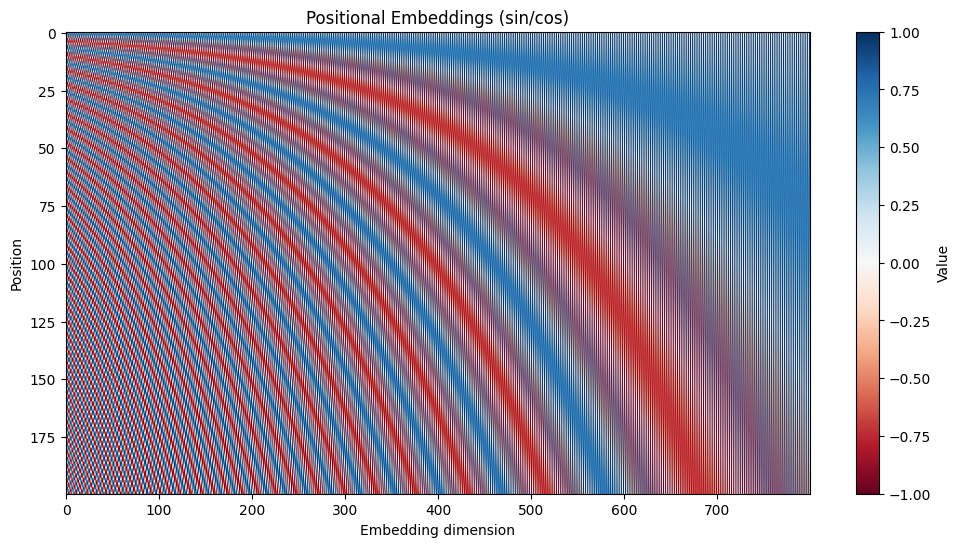

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.imshow(pos_embed.numpy(), aspect='auto', cmap='RdBu')
plt.colorbar(label='Value')
plt.xlabel('Embedding dimension')
plt.ylabel('Position')
plt.title('Positional Embeddings (sin/cos)')
plt.show()